# Day 7 — Module 3: Bivariate Relationships (Covariance & Correlation)
**Programme:** C-DAC PGCP-AI | **Course:** Data Analytics
**Student / Author:** abs6187 (`23f2000876@ds.study.iitm.ac.in`)

### Core Objectives:
1. **Covariance ($Cov(X, Y)$):** Definition, formula, directional interpretation, and scale limitations.
2. **Pearson Correlation Coefficient ($r$):** Scale-normalized linear association ($-1.0$ to $+1.0$).
3. **Spearman Rank Correlation ($\rho$):** Non-parametric monotonic relationship comparison.
4. **The $r \approx 0$ Non-Linear Trap:** Proving mathematically and visually why zero correlation does NOT imply independence.
5. **Bivariate OLS Linear Trendline:** Fitting slope $\beta_1 = \frac{Cov(X, Y)}{Var(X)}$ and intercept $\beta_0$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

# ==============================================================================
# 1. GENERATE BIVARIATE LINEAR RELATIONSHIP (Study Hours vs Exam Score)
# ==============================================================================
n = 150
study_hours = np.random.uniform(5, 45, n)
# True relationship: Exam Score = 40 + 1.25 * Hours + Gaussian Noise
noise = np.random.normal(0, 5, n)
exam_scores = 40.0 + 1.25 * study_hours + noise

# Compute Covariance (Sample, ddof=1)
cov_matrix = np.cov(study_hours, exam_scores, ddof=1)
cov_xy = cov_matrix[0, 1]

# Compute Pearson Correlation Coefficient
r_pearson, p_pearson = stats.pearsonr(study_hours, exam_scores)

# Compute Spearman Rank Correlation
rho_spearman, p_spearman = stats.spearmanr(study_hours, exam_scores)

# OLS Linear Regression line parameters
beta_1 = cov_xy / np.var(study_hours, ddof=1)
beta_0 = np.mean(exam_scores) - beta_1 * np.mean(study_hours)

print("=" * 65)
print("      BIVARIATE ANALYSIS: STUDY HOURS VS EXAM SCORES         ")
print("=" * 65)
print(f"Sample Size (n)               : {n}")
print(f"Sample Covariance Cov(X, Y)   : {cov_xy:.2f} (hours * marks)")
print(f"Pearson Correlation (r)       : {r_pearson:.4f} (p-value: {p_pearson:.3e})")
print(f"Spearman Rank Corr (rho)      : {rho_spearman:.4f} (p-value: {p_spearman:.3e})")
print(f"Regression Trendline Equation : Y = {beta_0:.2f} + {beta_1:.2f} * X")
print(f"R-squared (Variance Explained): {r_pearson**2:.4f} ({r_pearson**2 * 100:.1f}%)")
print("=" * 65)


      BIVARIATE ANALYSIS: STUDY HOURS VS EXAM SCORES         
Sample Size (n)               : 150
Sample Covariance Cov(X, Y)   : 178.94 (hours * marks)
Pearson Correlation (r)       : 0.9463 (p-value: 1.766e-74)
Spearman Rank Corr (rho)      : 0.9479 (p-value: 1.972e-75)
Regression Trendline Equation : Y = 39.71 + 1.27 * X
R-squared (Variance Explained): 0.8955 (89.6%)


### 2. The Critical Exam Trap: $r \approx 0$ Does NOT Mean Independence!
Pearson's $r$ measures strictly **linear** association. If $Y = X^2$ (a perfect parabola centered at 0), $Y$ is completely deterministic from $X$, yet Pearson's $r = 0.0$!

Below we contrast:
1. Strong Positive Linear ($r > 0.9$)
2. Strong Negative Linear ($r < -0.8$)
3. Quadratic Non-Linear ($Y = X^2$, $r \approx 0$)
4. Exponential Monotonic ($Y = e^X$, comparing Pearson vs Spearman)


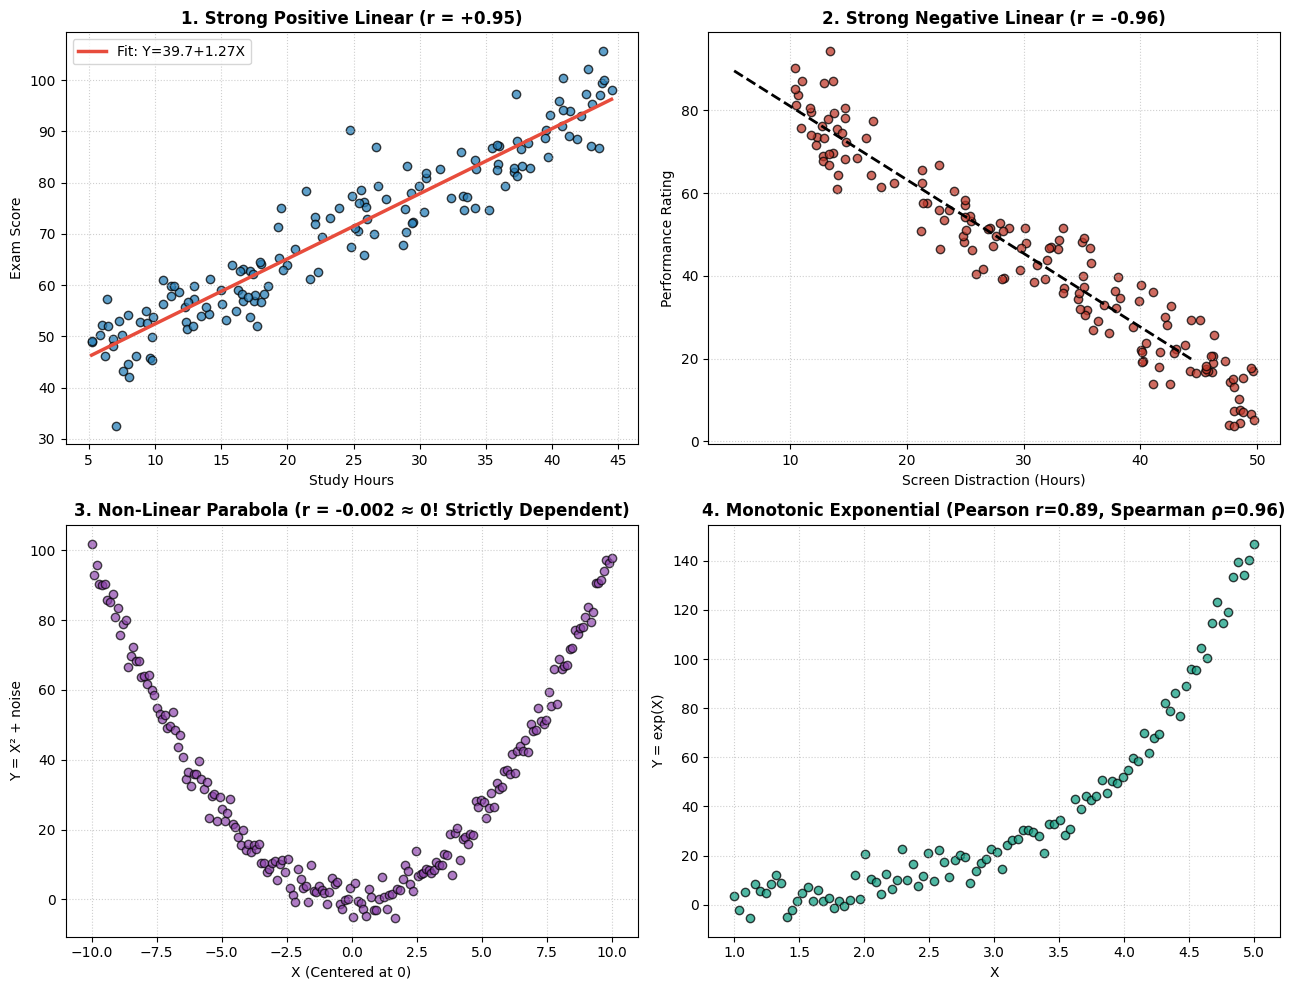

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- 1. Positive Linear ---
axes[0, 0].scatter(study_hours, exam_scores, color='#2980b9', alpha=0.75, edgecolor='black')
x_vals = np.linspace(study_hours.min(), study_hours.max(), 100)
axes[0, 0].plot(x_vals, beta_0 + beta_1 * x_vals, color='#e74c3c', linewidth=2.5, label=f'Fit: Y={beta_0:.1f}+{beta_1:.2f}X')
axes[0, 0].set_title(f'1. Strong Positive Linear (r = +{r_pearson:.2f})', fontweight='bold')
axes[0, 0].set_xlabel('Study Hours')
axes[0, 0].set_ylabel('Exam Score')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# --- 2. Negative Linear ---
x_neg = np.random.uniform(10, 50, n)
y_neg = 100 - 1.8 * x_neg + np.random.normal(0, 6, n)
r_neg, _ = stats.pearsonr(x_neg, y_neg)
axes[0, 1].scatter(x_neg, y_neg, color='#c0392b', alpha=0.75, edgecolor='black')
m_neg, b_neg = np.polyfit(x_neg, y_neg, 1)
axes[0, 1].plot(x_vals, b_neg + m_neg * x_vals, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_title(f'2. Strong Negative Linear (r = {r_neg:.2f})', fontweight='bold')
axes[0, 1].set_xlabel('Screen Distraction (Hours)')
axes[0, 1].set_ylabel('Performance Rating')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# --- 3. Non-Linear Trap: Y = X^2 ---
x_quad = np.linspace(-10, 10, 200)
y_quad = x_quad**2 + np.random.normal(0, 3, 200)
r_quad, _ = stats.pearsonr(x_quad, y_quad)
axes[1, 0].scatter(x_quad, y_quad, color='#8e44ad', alpha=0.7, edgecolor='black')
axes[1, 0].set_title(f'3. Non-Linear Parabola (r = {r_quad:+.3f} ≈ 0! Strictly Dependent)', fontweight='bold')
axes[1, 0].set_xlabel('X (Centered at 0)')
axes[1, 0].set_ylabel('Y = X² + noise')
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# --- 4. Monotonic Exponential: Pearson vs Spearman ---
x_exp = np.linspace(1, 5, 100)
y_exp = np.exp(x_exp) + np.random.normal(0, 5, 100)
r_p_exp, _ = stats.pearsonr(x_exp, y_exp)
r_s_exp, _ = stats.spearmanr(x_exp, y_exp)
axes[1, 1].scatter(x_exp, y_exp, color='#16a085', alpha=0.75, edgecolor='black')
axes[1, 1].set_title(f'4. Monotonic Exponential (Pearson r={r_p_exp:.2f}, Spearman ρ={r_s_exp:.2f})', fontweight='bold')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y = exp(X)')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
